In [2]:
# ============================================================
# BLOQUE 1 — CARGA UNIVERSAL DEL EXPERIMENTO
# ============================================================

import os
import sys
import glob
import yaml
import joblib

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

# ============================================================
# DETECCIÓN ROBUSTA DEL ROOT DEL PROYECTO
# ============================================================

current = Path.cwd()

while current.name != "eeg_hmm_project":

    if current.parent == current:
        raise RuntimeError(
            "❌ No se encontró la carpeta eeg_hmm_project"
        )

    current = current.parent

project_root = str(current)

print("=" * 60)
print("PROJECT ROOT")
print("=" * 60)
print(project_root)

# ------------------------------------------------------------
# YAML
# ------------------------------------------------------------

YAML_NAME = "feat_task_k4_full_pca90_fullfeatures_v2.yaml"

yaml_path = os.path.join(
    project_root,
    "configs",
    "experiments",
    "depured_methology_experiments",
    YAML_NAME
)

print("\nYAML:")
print(yaml_path)

with open(yaml_path, 'r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

exp_name = cfg['experiment']['name']

n_states = cfg['pipeline']['hmm']['k_states']

cov_type = cfg['pipeline']['hmm']['covariance_type']

print("\n" + "=" * 60)
print("EXPERIMENT CONFIG")
print("=" * 60)

print(f"Experiment: {exp_name}")
print(f"K States : {n_states}")
print(f"Cov Type : {cov_type}")

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def clean_path(path_str):

    limpio = (
        path_str
        .replace('../../', '')
        .replace('../', '')
    )

    return os.path.normpath(
        os.path.join(project_root, limpio)
    )

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

features_dir = clean_path(
    cfg['paths']['features_dir']
)

output_dir = clean_path(
    cfg['paths']['output_dir']
)

exp_dir = os.path.join(
    output_dir,
    exp_name
)

print("\n" + "=" * 60)
print("PATHS")
print("=" * 60)

print(f"Features Dir:\n{features_dir}")
print(f"\nExperiment Dir:\n{exp_dir}")

# ------------------------------------------------------------
# LOAD FEATURES
# ------------------------------------------------------------

feature_files = sorted(
    glob.glob(
        os.path.join(features_dir, '*_features.npy')
    )
)

print(f"\nFeatures files encontrados: {len(feature_files)}")

X_original = np.vstack([
    np.load(f)
    for f in feature_files
])

print(f"\nX_original shape: {X_original.shape}")

# ------------------------------------------------------------
# LOAD PCA MATRICES
# ------------------------------------------------------------

X_pca = np.load(
    os.path.join(exp_dir, 'X_pca.npy')
)

print(f"X_pca shape: {X_pca.shape}")

# ------------------------------------------------------------
# LOAD VITERBI
# ------------------------------------------------------------

viterbi_paths = np.load(
    os.path.join(
        exp_dir,
        f'viterbi_paths_k{n_states}.npy'
    )
)

print(f"Viterbi shape: {viterbi_paths.shape}")

# ------------------------------------------------------------
# LOAD MODEL
# ------------------------------------------------------------

model = joblib.load(
    os.path.join(
        exp_dir,
        f'hmm_model_k{n_states}.pkl'
    )
)

print("\n✅ Modelo cargado correctamente")

# ------------------------------------------------------------
# LOAD SCALER
# ------------------------------------------------------------

scaler = joblib.load(
    os.path.join(exp_dir, 'scaler.pkl')
)

X_scaled = scaler.transform(X_original)

print(f"\nX_scaled shape: {X_scaled.shape}")

# ------------------------------------------------------------
# SANITY CHECK
# ------------------------------------------------------------

assert len(viterbi_paths) == X_scaled.shape[0]

print("\n✅ Sanity check superado")

PROJECT ROOT
c:\Proyectos\eeg_hmm_project

YAML:
c:\Proyectos\eeg_hmm_project\configs\experiments\depured_methology_experiments\feat_task_k4_full_pca90_fullfeatures_v2.yaml

EXPERIMENT CONFIG
Experiment: feat_task_k4_full_pca90_fullfeatures_v2
K States : 4
Cov Type : full

PATHS
Features Dir:
c:\Proyectos\eeg_hmm_project\data\interim\features\task_fullfeatures_v2

Experiment Dir:
c:\Proyectos\eeg_hmm_project\outputs\processed\experiments\feature_hmm\task\feat_task_k4_full_pca90_fullfeatures_v2

Features files encontrados: 118

X_original shape: (25949, 114)
X_pca shape: (25949, 59)
Viterbi shape: (25949,)

✅ Modelo cargado correctamente

X_scaled shape: (25949, 114)

✅ Sanity check superado


In [3]:
# ============================================================
# BLOQUE 2 — DISTRIBUCIÓN GLOBAL
# ============================================================

print("=" * 60)
print(f"Distribución Global de Hidden States (K={n_states})")
print("=" * 60)

total_windows = len(viterbi_paths)

print(f"Total de ventanas: {total_windows:,}\n")

for s in range(n_states):

    count = np.sum(viterbi_paths == s)

    frac = count / total_windows

    print(
        f"State {s}: "
        f"{frac:.2%} "
        f"(n={count:,})"
    )

Distribución Global de Hidden States (K=4)
Total de ventanas: 25,949

State 0: 6.77% (n=1,756)
State 1: 36.73% (n=9,531)
State 2: 24.19% (n=6,276)
State 3: 32.32% (n=8,386)


In [4]:
# ============================================================
# BLOQUE 3 — TRANSITION MATRIX
# ============================================================

transmat = model.transmat_

df_trans = pd.DataFrame(
    np.round(transmat, 3),
    columns=[f"To S{i}" for i in range(n_states)],
    index=[f"From S{i}" for i in range(n_states)]
)

print("=" * 60)
print("TRANSITION MATRIX")
print("=" * 60)

display(df_trans)

# ------------------------------------------------------------
# SELF TRANSITIONS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("STATE PERSISTENCE")
print("=" * 60)

for s in range(n_states):

    occupancy = np.mean(viterbi_paths == s)

    persistence = transmat[s, s]

    count = np.sum(viterbi_paths == s)

    print(f"\nState {s}")
    print("-" * 20)

    print(f"Fractional Occupancy : {occupancy:.4f}")
    print(f"Total Windows        : {count:,}")
    print(f"Self-transition      : {persistence:.4f}")

TRANSITION MATRIX


,To S0,To S1,To S2,To S3
From S0,1.0,0.000,0.000,0.000
From S1,0.0,0.952,0.043,0.005
From S2,0.0,0.052,0.904,0.045
From S3,0.0,0.002,0.054,0.944



STATE PERSISTENCE

State 0
--------------------
Fractional Occupancy : 0.0677
Total Windows        : 1,756
Self-transition      : 1.0000

State 1
--------------------
Fractional Occupancy : 0.3673
Total Windows        : 9,531
Self-transition      : 0.9525

State 2
--------------------
Fractional Occupancy : 0.2419
Total Windows        : 6,276
Self-transition      : 0.9036

State 3
--------------------
Fractional Occupancy : 0.3232
Total Windows        : 8,386
Self-transition      : 0.9441


['Theta', 'Alpha', 'Beta', 'Mobility', 'Complexity', 'Entropy']
(4, 114)


C:\Users\pokem\AppData\Local\Temp\ipykernel_7692\2134628683.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


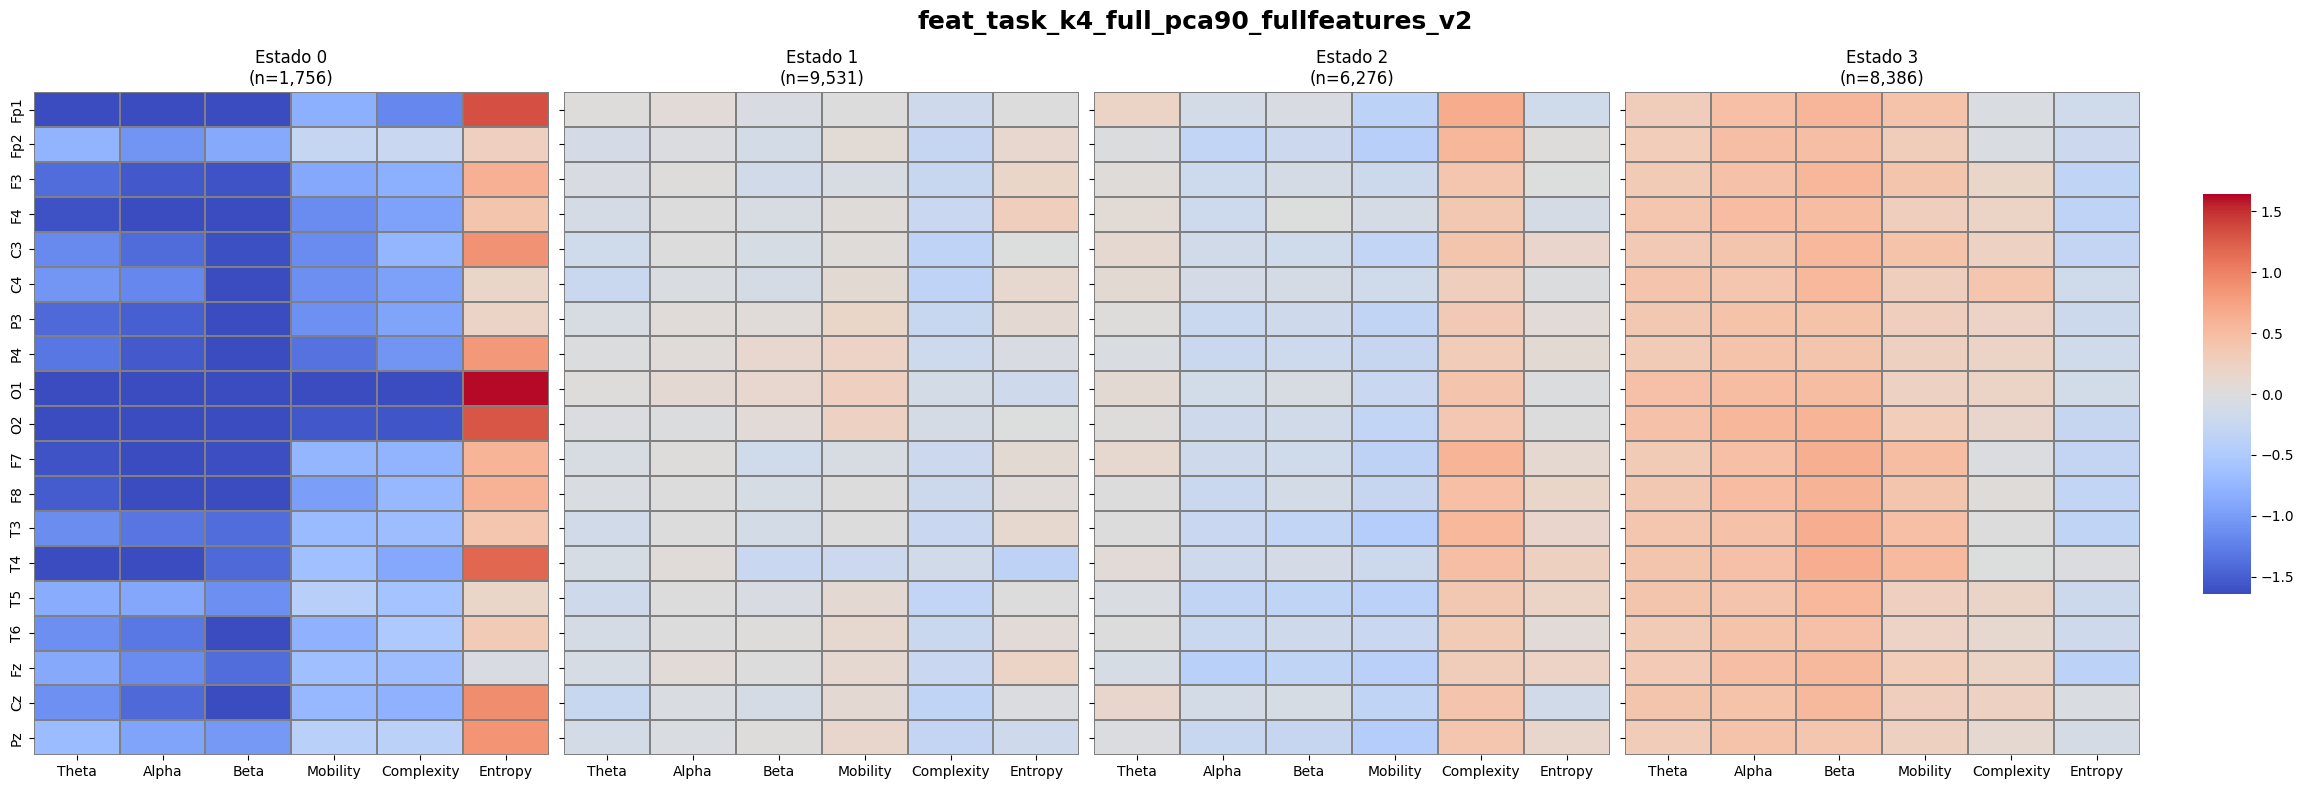

In [5]:
# ============================================================
# BLOQUE 4 — STATE PROFILES
# ============================================================

feature_flags = cfg['features']

metrics = []

if feature_flags['use_theta']:
    metrics.append('Theta')

if feature_flags['use_alpha']:
    metrics.append('Alpha')

if feature_flags['use_beta']:
    metrics.append('Beta')

if feature_flags['use_hjorth']:
    metrics.extend(['Mobility', 'Complexity'])

if feature_flags['use_entropy']:
    metrics.append('Entropy')

print(metrics)

# ------------------------------------------------------------
# CHANNELS
# ------------------------------------------------------------

ch_names = [
    'Fp1','Fp2','F3','F4','C3','C4','P3','P4',
    'O1','O2','F7','F8','T3','T4','T5','T6',
    'Fz','Cz','Pz'
]

# ------------------------------------------------------------
# STATE PROFILES
# ------------------------------------------------------------

state_profiles = []

for s in range(n_states):

    idx = (viterbi_paths == s)

    mean_profile = np.mean(
        X_scaled[idx],
        axis=0
    )

    state_profiles.append(mean_profile)

state_profiles = np.array(state_profiles)

print(state_profiles.shape)

# ------------------------------------------------------------
# RESHAPE
# ------------------------------------------------------------

n_channels = len(ch_names)

state_profiles_3d = np.zeros(
    (
        n_states,
        n_channels,
        len(metrics)
    )
)

for m_idx in range(len(metrics)):

    start = m_idx * n_channels
    end = (m_idx + 1) * n_channels

    state_profiles_3d[:, :, m_idx] = (
        state_profiles[:, start:end]
    )

# ------------------------------------------------------------
# VISUALIZATION
# ------------------------------------------------------------

global_absmax = np.percentile(
    np.abs(state_profiles_3d),
    95
)

fig, axes = plt.subplots(
    1,
    n_states,
    figsize=(6 * n_states, 8),
    sharey=True
)

if n_states == 1:
    axes = [axes]

cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])

for s in range(n_states):

    ax = axes[s]

    sns.heatmap(
        state_profiles_3d[s],
        cmap='coolwarm',
        center=0,
        vmin=-global_absmax,
        vmax=global_absmax,
        xticklabels=metrics,
        yticklabels=ch_names,
        linewidths=0.3,
        linecolor='gray',
        ax=ax,
        cbar=(s == 0),
        cbar_ax=None if s > 0 else cbar_ax
    )

    n_windows = np.sum(viterbi_paths == s)

    ax.set_title(
        f"Estado {s}\n(n={n_windows:,})"
    )

plt.suptitle(
    f"{exp_name}",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 0.9, 1])

plt.show()

COSINE SIMILARITY MATRIX
[[ 1.      0.1881  0.199  -0.9104]
 [ 0.1881  1.     -0.5536 -0.2919]
 [ 0.199  -0.5536  1.     -0.4128]
 [-0.9104 -0.2919 -0.4128  1.    ]]


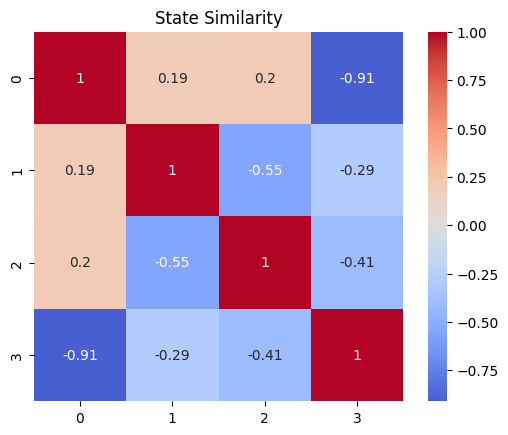

In [6]:
# ============================================================
# BLOQUE 5 — COSINE SIMILARITY
# ============================================================

from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(
    state_profiles
)

print("=" * 60)
print("COSINE SIMILARITY MATRIX")
print("=" * 60)

print(
    np.round(similarity_matrix, 4)
)

sns.heatmap(
    similarity_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    square=True
)

plt.title("State Similarity")

plt.show()

In [7]:
# ============================================================
# BLOQUE 6 — DWELL TIMES
# ============================================================

STEP_SIZE_MS = 100

print("=" * 60)
print("DWELL TIMES")
print("=" * 60)

for s in range(n_states):

    runs = []

    current_run = 0

    for val in viterbi_paths:

        if val == s:
            current_run += 1

        else:
            if current_run > 0:
                runs.append(current_run)

            current_run = 0

    if current_run > 0:
        runs.append(current_run)

    dwell_ms = np.mean(runs) * STEP_SIZE_MS

    print(
        f"State {s}: "
        f"{dwell_ms:.2f} ms"
    )

DWELL TIMES
State 0: 29266.67 ms
State 1: 1973.29 ms
State 2: 718.90 ms
State 3: 1680.56 ms
